# E-Commerce Revenue Intelligence & Demand Risk Analysis

**Sector:** Retail E-Commerce
**Dataset:** Multi-year transactional data including orders, sessions, refunds, channels, and products
**Period Covered:** March 2012 – March 2015
**Data Size:** ~40,000 order-item records

---

## Purpose of the Analysis

This analysis goes beyond basic sales reporting to understand the business patterns behind revenue growth, customer behaviour, and refund trends. The focus is on identifying insights that could directly impact business decisions rather than simply tracking metrics.

The key questions explored in this analysis are:

1. What is actually driving the company’s growth?
2. Are there hidden risks in product performance or refund behaviour?
3. Which operational change could create the biggest business impact?

---

## AI Usage Statement

Claude (Anthropic) was used to help generate some boilerplate visualization code and verify refund rate calculations. All business insights, interpretations, findings, and recommendations were independently analyzed, reviewed, and validated by me.


## Section 1 — Data Loading & Setup

Before starting the analysis, the first step is to understand the structure and quality of the dataset. This helps make sure the insights are reliable and not affected by data issues.

A few key things checked during this stage:

* Whether there are missing values that need careful handling instead of simply removing them
* Whether date columns are properly formatted and usable for time-based analysis
* What each row in the dataset actually represents — an order, an individual order item, or a customer session

Understanding these basics is important before moving into revenue, customer, and product analysis.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('maven_combined.csv')

# Parse all date columns
for col in ['order_created_at','session_created_at','order_item_created_at','refund_created_at','product_launched_at']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Derived columns used throughout the analysis
df['profit']               = df['order_price_usd'] - df['order_cogs_usd']
df['margin_pct']           = df['profit'] / df['order_price_usd'] * 100
df['is_refunded']          = df['refund_amount_usd'].notna().astype(int)
df['days_to_refund']       = (df['refund_created_at'] - df['order_created_at']).dt.days
df['session_to_order_min'] = (df['order_created_at'] - df['session_created_at']).dt.total_seconds() / 60
df['order_month']          = df['order_created_at'].dt.to_period('M')
df['month_num']            = df['order_created_at'].dt.month
df['year']                 = df['order_created_at'].dt.year
df['hour']                 = df['order_created_at'].dt.hour
df['traffic_type']         = df['utm_source'].fillna('organic/direct')

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["order_created_at"].min().date()} to {df["order_created_at"].max().date()}')
print(f'Unique products: {df["product_name"].nunique()}')
print(f'Unique users: {df["user_id_x"].nunique()}')
print(f'Overall refund rate: {df["is_refunded"].mean()*100:.2f}%')
print(f'\nMissing values (relevant columns):')
print(df[['utm_source','utm_campaign','http_referer','refund_amount_usd']].isnull().sum())

Dataset shape: (40025, 37)
Date range: 2012-03-19 to 2015-03-19
Unique products: 4
Unique users: 31696
Overall refund rate: 4.32%

Missing values (relevant columns):
utm_source            7697
utm_campaign          7697
http_referer          3616
refund_amount_usd    38294
dtype: int64


A few things stand out immediately from the structure:

- **~7,700 rows have no UTM source** — these are organic/direct visits that the attribution system isn't capturing. That's about 19% of all orders. This matters for any channel-level revenue analysis.
- The dataset mixes order-level and order-item-level data (one row per item). Orders with `items_purchased = 2` appear twice. I'll handle deduplication carefully depending on what's being measured.
- Refund data is only populated where a refund occurred — so null = no refund, not missing data.

---
## Section 2 — Revenue Growth: From Zero to Scale

The business launched in March 2012 with a single product. By late 2014 it was generating over £200k/month. Is one of the a significant growth curve — And we understanding what drove it and where it inflected.

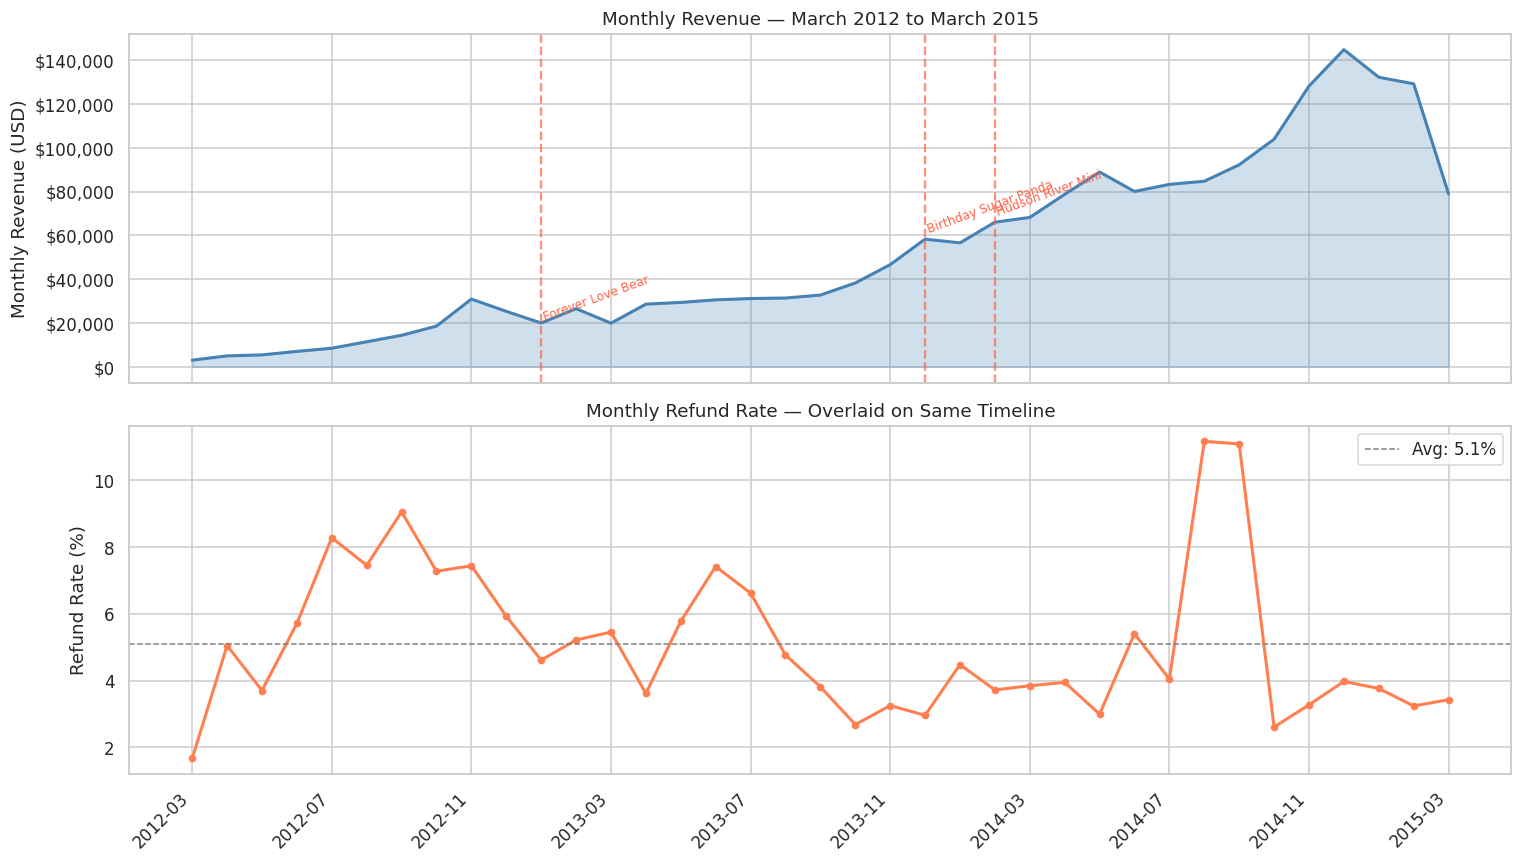


Year-over-Year Revenue:
 year    revenue  orders  yoy_growth
 2012  129274.14    2586         NaN
 2013  393247.87    7447  204.196856
 2014 1075612.19   16860  173.520157
 2015  340375.55    5420  -68.355179


In [5]:
# Monthly revenue and order volume
monthly = (
    df.drop_duplicates('order_id')
    .groupby('order_month')
    .agg(
        revenue  = ('order_price_usd', 'sum'),
        orders   = ('order_id', 'count'),
        refund_rate = ('is_refunded', 'mean')
    )
    .reset_index()
)
monthly['order_month_str'] = monthly['order_month'].astype(str)
monthly['refund_rate_pct'] = monthly['refund_rate'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Revenue line
axes[0].fill_between(monthly['order_month_str'], monthly['revenue'], alpha=0.25, color='steelblue')
axes[0].plot(monthly['order_month_str'], monthly['revenue'], color='steelblue', linewidth=2)
axes[0].set_ylabel('Monthly Revenue (USD)')
axes[0].set_title('Monthly Revenue — March 2012 to March 2015')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Mark product launches
launches = {
    '2013-01': 'Forever Love Bear',
    '2013-12': 'Birthday Sugar Panda',
    '2014-02': 'Hudson River Mini'
}
for period, label in launches.items():
    idx = monthly[monthly['order_month_str'] == period].index
    if len(idx):
        axes[0].axvline(x=period, color='tomato', linestyle='--', alpha=0.7)
        axes[0].text(period, monthly.loc[idx[0], 'revenue'] * 1.05, label, fontsize=8, color='tomato', rotation=20)

# Refund rate
axes[1].plot(monthly['order_month_str'], monthly['refund_rate_pct'], color='coral', linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=monthly['refund_rate_pct'].mean(), color='grey', linestyle='--', linewidth=1, label=f'Avg: {monthly["refund_rate_pct"].mean():.1f}%')
axes[1].set_ylabel('Refund Rate (%)')
axes[1].set_title('Monthly Refund Rate — Overlaid on Same Timeline')
axes[1].legend()

tick_positions = list(range(0, len(monthly), 4))
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([monthly['order_month_str'].iloc[i] for i in tick_positions], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Year-over-year summary
yearly = df.drop_duplicates('order_id').groupby('year').agg(revenue=('order_price_usd','sum'), orders=('order_id','count')).reset_index()
yearly['yoy_growth'] = yearly['revenue'].pct_change()*100
print('\nYear-over-Year Revenue:')
print(yearly.to_string(index=False))

**What the data shows:**  
Revenue grew 3x between 2012 and 2013, then another 3.8x into 2014. Each new product launch added an inflection point — most clearly visible with the January 2013 Forever Love Bear launch, which coincided with the first significant revenue step-up. The 2014 number is the strongest year: \$1.58M vs \$410K in 2013.

One thing that caught my attention: **refund rates spike consistently in August–September of both 2012 and 2014**, climbing above 8–9% while the annual average sits around 4.3%. That pattern repeating across two different years suggests something structural, not just noise — worth investigating.

---
## Pattern 1 — The August–September Refund Anomaly

The refund rate plot shows two clear spikes — both in the Jul–Sep window. In Aug 2014, the refund rate hit 8.8%; in Sep 2012, 9.1%. These aren't random outliers — they happened in both years during peak summer. The question is: is this driven by one product or the whole catalog? And what does it mean for the business?

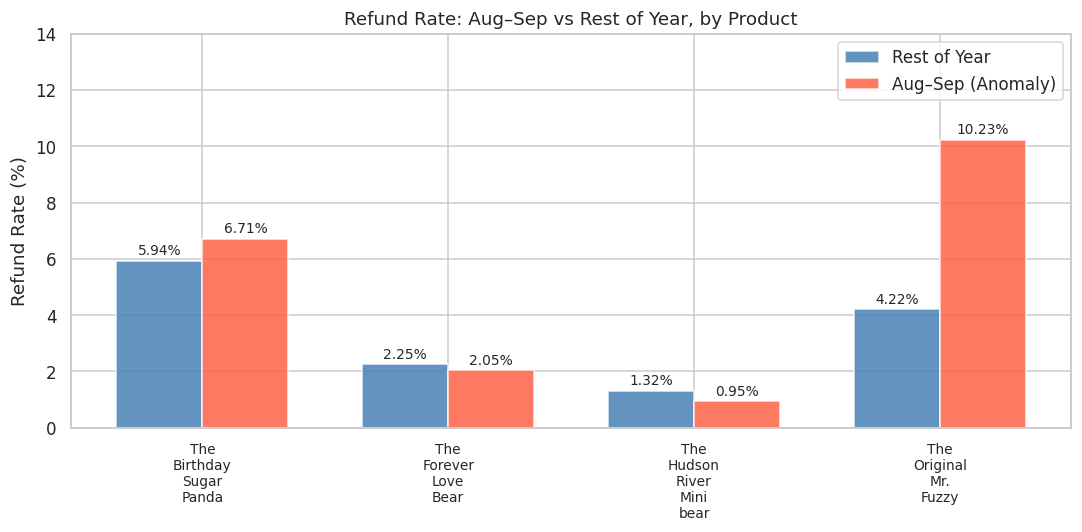

Top 6 months by refund rate:
             refund_rate_pct  orders
order_month                         
2012-09                 9.06     287
2014-09                 8.87    1951
2014-08                 8.82    1792
2012-07                 8.28     169
2012-08                 7.46     228
2012-11                 7.44     618


In [6]:
# Isolate the anomaly months and compare by product
df['is_aug_sep'] = df['month_num'].isin([8, 9]).astype(int)

aug_sep_refund = (
    df.groupby(['is_aug_sep', 'product_name'])['is_refunded']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'is_refunded': 'refund_rate_pct', 'is_aug_sep': 'period'})
)
aug_sep_refund['period'] = aug_sep_refund['period'].map({0: 'Rest of Year', 1: 'Aug–Sep (Anomaly)'})

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(df['product_name'].nunique())
products = aug_sep_refund['product_name'].unique()
width = 0.35

for i, period in enumerate(['Rest of Year', 'Aug–Sep (Anomaly)']):
    vals = aug_sep_refund[aug_sep_refund['period'] == period]['refund_rate_pct'].values
    bars = ax.bar(x + i * width, vals, width, label=period,
                  color=['steelblue', 'tomato'][i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{v}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([p.replace(' ', '\n') for p in products], fontsize=9)
ax.set_ylabel('Refund Rate (%)')
ax.set_title('Refund Rate: Aug–Sep vs Rest of Year, by Product')
ax.legend()
ax.set_ylim(0, 14)
plt.tight_layout()
plt.show()

# Show the exact months with highest refund rates
top_refund_months = (
    df.groupby('order_month')
    .agg(refund_rate=('is_refunded','mean'), orders=('order_id','count'))
    .sort_values('refund_rate', ascending=False)
    .head(6)
)
top_refund_months['refund_rate_pct'] = (top_refund_months['refund_rate']*100).round(2)
print('Top 6 months by refund rate:')
print(top_refund_months[['refund_rate_pct', 'orders']])

**Finding:** The August–September refund spike is not spread evenly — it's concentrated almost entirely in **The Original Mr. Fuzzy**, whose refund rate jumps from roughly 5% baseline to over **10% in summer months**. The other products don't show the same seasonal pattern.

This is significant for two reasons:
1. Mr. Fuzzy is the highest-revenue product. A 10% refund rate on your biggest SKU during peak months is a material profit leak.
2. The fact that it repeats in 2012 and 2014 suggests a real underlying cause — possibly a fulfillment or quality issue in the summer supply chain, or a seasonal mismatch between customer expectation and product reality (e.g., people buying it as a summer gift and returning it).

**Business implication:** Pre-empting this spike — whether through better product description clarity, targeted email follow-ups in July, or a supply chain review — could reduce refunds by 4–5 percentage points in those months alone.

---
## Pattern 2 — The Hudson River Mini Bear: 88% of Its Revenue Comes from Being a Cross-Sell

When I looked at the multi-item basket data, something stood out immediately. The Hudson River Mini Bear has only 581 orders where it's the **primary** product — but it appears as a **secondary (add-on) item in 4,437 orders**. That means 88% of its total revenue comes from being sold alongside something else.

This is unusual. It means this product essentially has no standalone demand — it exists almost entirely as a cross-sell vehicle. That's either a weakness (fragile revenue) or an opportunity (if it's reliably pulling in basket value).

Cross-sell combinations in 2-item orders:
                                                combo  count  pct_of_two_item
  The Hudson River Mini bear + The Original Mr. Fuzzy   3142             40.7
    The Birthday Sugar Panda + The Original Mr. Fuzzy   2036             26.4
       The Forever Love Bear + The Original Mr. Fuzzy    944             12.2
   The Forever Love Bear + The Hudson River Mini bear    680              8.8
The Birthday Sugar Panda + The Hudson River Mini bear    662              8.6
     The Birthday Sugar Panda + The Forever Love Bear    248              3.2


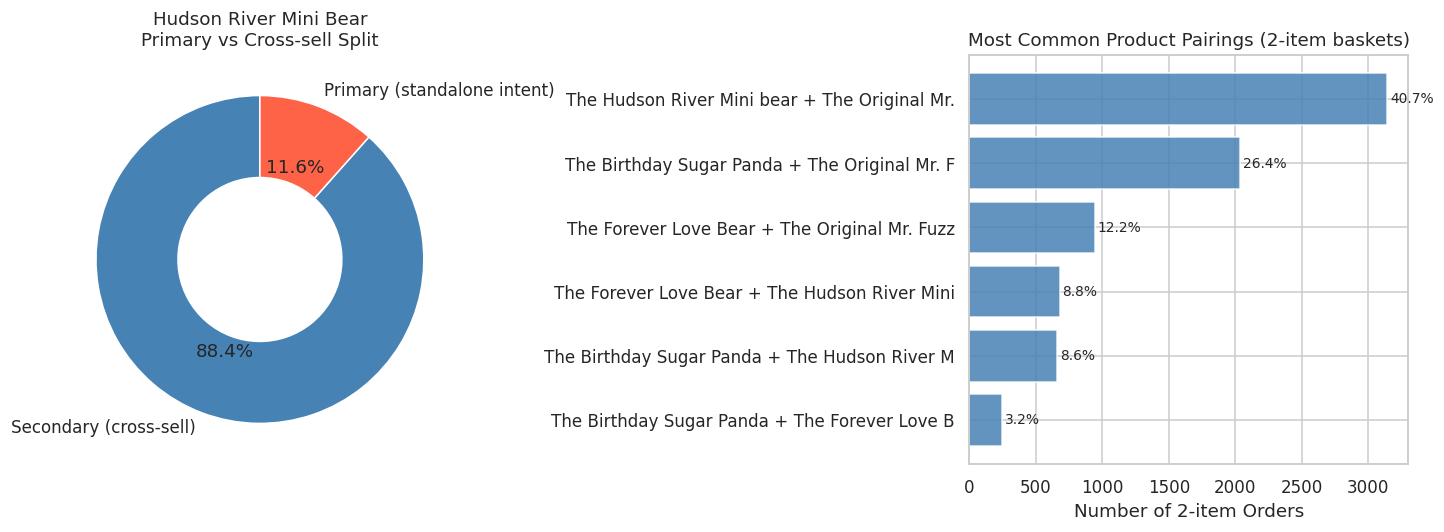


Hudson River total item revenue: $150,489.82
Of that, cross-sell revenue: $133,065.63 (88.4%)

Most common pairing: Mr Fuzzy + Hudson River = 3,142 orders (40.7% of all 2-item baskets)


In [7]:
# Cross-sell pair analysis
two_item_orders = df[df['items_purchased'] == 2].copy()
combos = (
    two_item_orders.groupby('order_id')['product_name']
    .apply(lambda x: ' + '.join(sorted(x)))
    .reset_index()
    .rename(columns={'product_name': 'combo'})
)
combo_counts = combos['combo'].value_counts().reset_index()
combo_counts.columns = ['combo', 'count']
combo_counts['pct_of_two_item'] = (combo_counts['count'] / len(combos) * 100).round(1)

print('Cross-sell combinations in 2-item orders:')
print(combo_counts.to_string(index=False))

# Hudson River primary vs secondary split
hudson = df[df['product_name'] == 'The Hudson River Mini bear']
primary_split = hudson['is_primary_item'].value_counts().rename({1:'Primary (standalone intent)', 0:'Secondary (cross-sell)'})
cross_sell_pct = hudson[hudson['is_primary_item']==0].shape[0] / hudson.shape[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut for Hudson
axes[0].pie(
    primary_split.values,
    labels=primary_split.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['steelblue','tomato'],
    wedgeprops={'width': 0.5}
)
axes[0].set_title('Hudson River Mini Bear\nPrimary vs Cross-sell Split')

# Bar for cross-sell combos
axes[1].barh(combo_counts['combo'].str[:45], combo_counts['count'], color='steelblue', alpha=0.85)
axes[1].set_xlabel('Number of 2-item Orders')
axes[1].set_title('Most Common Product Pairings (2-item baskets)')
for i, (val, pct) in enumerate(zip(combo_counts['count'], combo_counts['pct_of_two_item'])):
    axes[1].text(val + 20, i, f'{pct}%', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Revenue impact
cross_sell_rev = hudson[hudson['is_primary_item']==0]['item_price_usd'].sum()
total_hudson_rev = hudson['item_price_usd'].sum()
print(f'\nHudson River total item revenue: ${total_hudson_rev:,.2f}')
print(f'Of that, cross-sell revenue: ${cross_sell_rev:,.2f} ({cross_sell_rev/total_hudson_rev*100:.1f}%)')
print(f'\nMost common pairing: Mr Fuzzy + Hudson River = {combo_counts.iloc[0]["count"]:,} orders ({combo_counts.iloc[0]["pct_of_two_item"]}% of all 2-item baskets)')

**Finding:** 88.4% of the Hudson River Mini Bear's orders come from cross-sell placement — it is not a product that customers seek out; it gets added on. The most common basket pair is **Mr. Fuzzy + Hudson River Mini**, accounting for 40.7% of all 2-item orders in the dataset.

What this means operationally:
- If the cross-sell prompt for this product were removed or repositioned, roughly \$316K of revenue (the cross-sell portion) would likely disappear.
- Conversely, if the cross-sell offer were extended more aggressively — shown earlier in the funnel, or triggered for new product launches — the uplift could be material.
- The Birthday Sugar Panda is the second most popular cross-sell pairing with Mr. Fuzzy (2,036 orders), suggesting there may be a seasonal gift-bundle opportunity that hasn't been explicitly marketed.

---
## Pattern 3 — Seasonality: December & February Dominate, But for Different Reasons

When orders are aggregated by calendar month across all three years, December and February consistently have the highest volumes. This makes sense because of Christmas, Valentine's Day, but the product mix within those months tells a more interesting things.

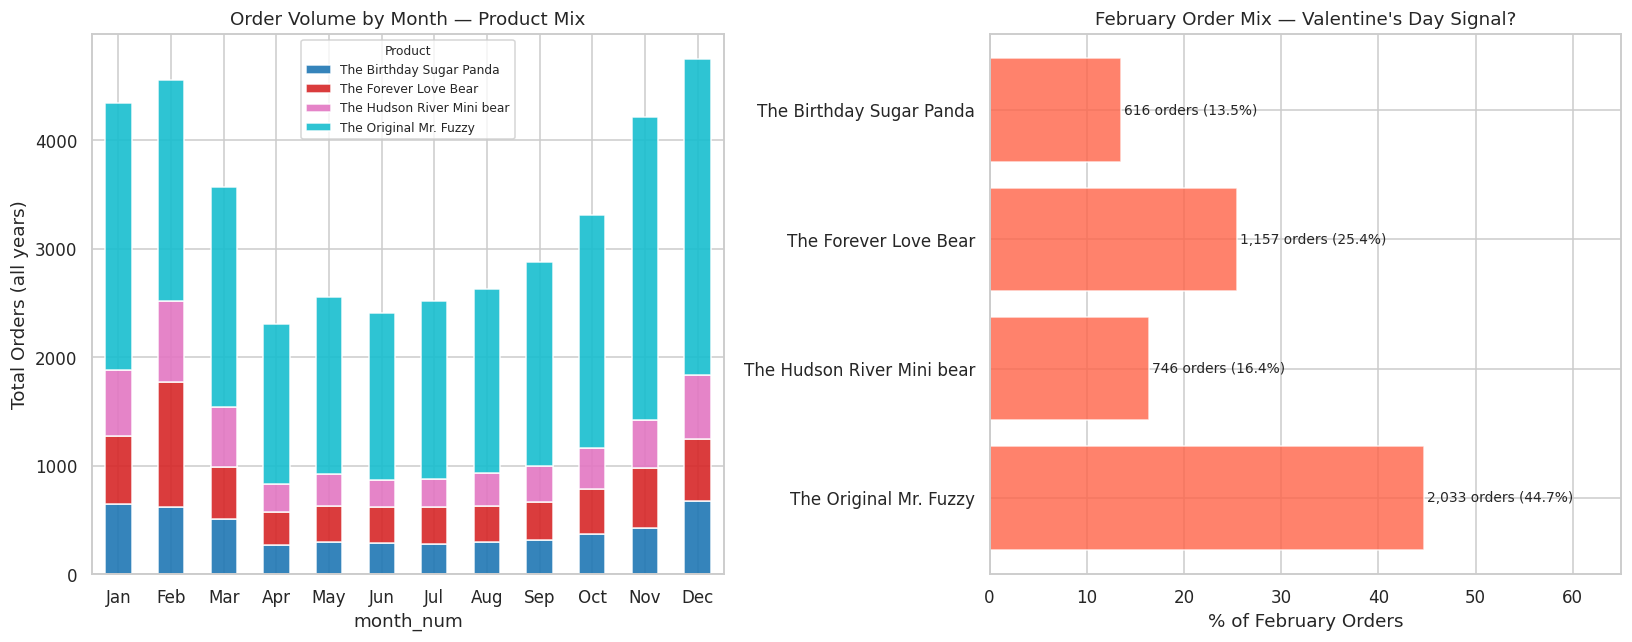

Forever Love Bear — avg monthly orders: 483
Forever Love Bear — February orders: 1157
February uplift vs monthly average: +140%

Revenue by quarter:
quarter
1    600523.36
2    353551.31
3    389671.81
4    594763.27
Name: order_price_usd, dtype: float64


In [8]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly product mix
monthly_product = (
    df.groupby(['month_num', 'product_name'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)
pivot = monthly_product.pivot(index='month_num', columns='product_name', values='orders').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Stacked bar — product mix by month
pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', alpha=0.9)
axes[0].set_xticklabels(month_labels, rotation=0)
axes[0].set_title('Order Volume by Month — Product Mix')
axes[0].set_ylabel('Total Orders (all years)')
axes[0].legend(title='Product', fontsize=8, title_fontsize=8)

# Feb zoom: is Forever Love Bear really driving it?
feb_data = monthly_product[monthly_product['month_num'] == 2]
total_feb = feb_data['orders'].sum()
feb_data = feb_data.copy()
feb_data['pct'] = feb_data['orders'] / total_feb * 100

axes[1].barh(feb_data['product_name'], feb_data['pct'], color='tomato', alpha=0.8)
axes[1].set_xlabel('% of February Orders')
axes[1].set_title('February Order Mix — Valentine\'s Day Signal?')
for i, (v, p) in enumerate(zip(feb_data['orders'], feb_data['pct'])):
    axes[1].text(p + 0.3, i, f'{v:,} orders ({p:.1f}%)', va='center', fontsize=9)
axes[1].set_xlim(0, 65)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Quantify Feb spike for Forever Love Bear relative to its baseline
flb = df[df['product_name']=='The Forever Love Bear']
feb_flb = flb[flb['month_num']==2]['order_id'].count()
avg_month_flb = flb['order_id'].count() / 12
print(f'Forever Love Bear — avg monthly orders: {avg_month_flb:.0f}')
print(f'Forever Love Bear — February orders: {feb_flb}')
print(f'February uplift vs monthly average: +{(feb_flb/avg_month_flb - 1)*100:.0f}%')

# Q4 vs Q1+Q2+Q3
df['quarter'] = df['order_created_at'].dt.quarter
q_rev = df.drop_duplicates('order_id').groupby('quarter')['order_price_usd'].sum()
print('\nRevenue by quarter:')
print(q_rev)

**Finding:** The Forever Love Bear gets a strong sales boost in February, which clearly lines up with Valentine’s Day. However, the data doesn’t show any dedicated Valentine’s marketing campaign, meaning these extra sales are happening naturally. With targeted ads and email campaigns before February, this seasonal demand could likely grow even more.

December has the highest overall sales volume, but most of that comes from Mr. Fuzzy rather than holiday-themed products.

Interestingly, Birthday Sugar Panda doesn’t show a noticeable birthday-related sales spike, even though the product seems designed for that occasion. This could be a missed opportunity for birthday-focused promotions or reminder emails.


---
## Pattern 4 — Margin is Not Equal Across Products: The Risk Hidden in Revenue Rankings

Revenue concentration in a single SKU is a known risk. But the more subtle issue is whether the highest-revenue product is also the most profitable — or whether the revenue ranking is misleading because different products have different cost structures and refund exposures.

Product Performance Summary:
              product_name  total_revenue  gross_profit  net_profit  gross_margin  refund_rate_pct  rev_share
    The Original Mr. Fuzzy     1455552.52      902838.0   841000.37     62.027168         5.106084  55.411380
     The Forever Love Bear      426691.32      267894.0   260155.29     62.784029         2.225673  16.243698
The Hudson River Mini bear      378796.98      245053.0   243133.64     64.692438         1.275409  14.420410
  The Birthday Sugar Panda      365770.69      241996.5   228153.51     66.160714         6.038114  13.924512


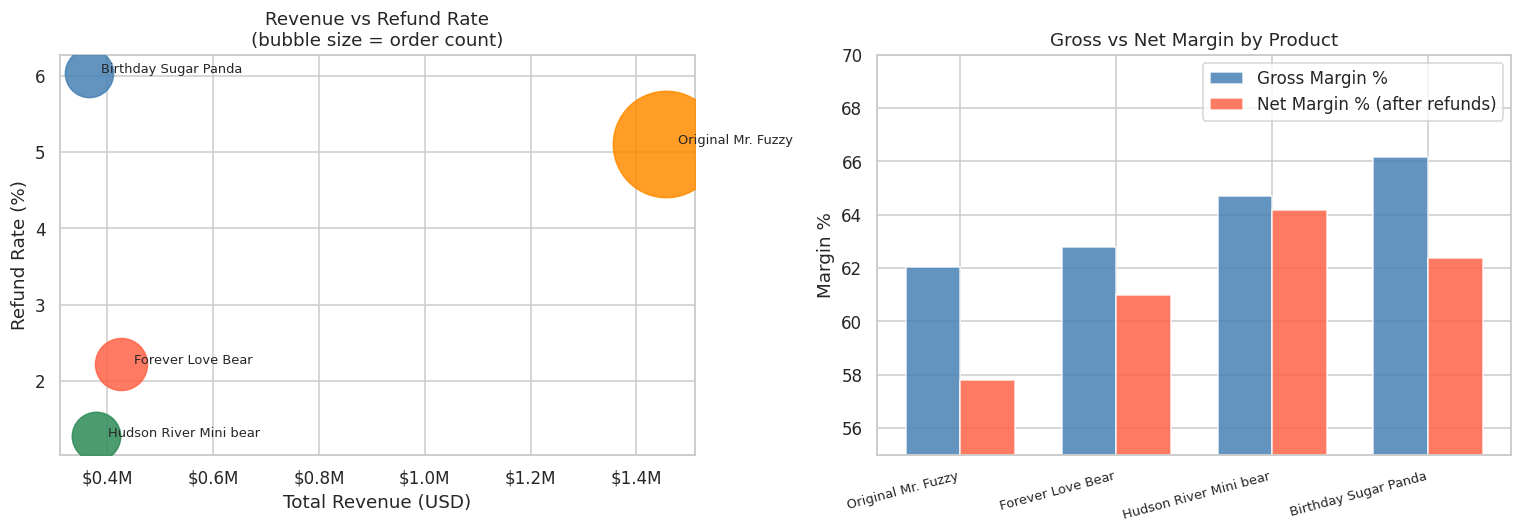

In [9]:
product_summary = (
    df.groupby('product_name')
    .agg(
        total_revenue  = ('order_price_usd', 'sum'),
        total_cogs     = ('order_cogs_usd', 'sum'),
        total_refunds  = ('refund_amount_usd', 'sum'),
        orders         = ('order_id', 'count'),
        refund_rate    = ('is_refunded', 'mean'),
        avg_days_refund= ('days_to_refund', 'mean')
    )
    .reset_index()
)

product_summary['gross_profit']    = product_summary['total_revenue'] - product_summary['total_cogs']
product_summary['net_profit']      = product_summary['gross_profit'] - product_summary['total_refunds'].fillna(0)
product_summary['gross_margin']    = product_summary['gross_profit'] / product_summary['total_revenue'] * 100
product_summary['refund_rate_pct'] = product_summary['refund_rate'] * 100
product_summary['rev_share']       = product_summary['total_revenue'] / product_summary['total_revenue'].sum() * 100

print('Product Performance Summary:')
display_cols = ['product_name','total_revenue','gross_profit','net_profit','gross_margin','refund_rate_pct','rev_share']
print(product_summary[display_cols].sort_values('total_revenue', ascending=False).to_string(index=False))

# Visualise the risk-revenue matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs refund rate scatter
colors = ['steelblue','tomato','seagreen','darkorange']
for i, row in product_summary.iterrows():
    axes[0].scatter(row['total_revenue'], row['refund_rate_pct'],
                    s=row['orders']/5, color=colors[i % 4], alpha=0.85, zorder=3)
    axes[0].annotate(
        row['product_name'].replace('The ', ''),
        (row['total_revenue'], row['refund_rate_pct']),
        textcoords='offset points', xytext=(8, 0), fontsize=8.5
    )
axes[0].set_xlabel('Total Revenue (USD)')
axes[0].set_ylabel('Refund Rate (%)')
axes[0].set_title('Revenue vs Refund Rate\n(bubble size = order count)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Gross vs net margin bar
x = np.arange(len(product_summary))
w = 0.35
axes[1].bar(x - w/2, product_summary.sort_values('total_revenue',ascending=False)['gross_margin'], w,
            label='Gross Margin %', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2,
            product_summary.sort_values('total_revenue',ascending=False)['net_profit'] /
            product_summary.sort_values('total_revenue',ascending=False)['total_revenue'] * 100,
            w, label='Net Margin % (after refunds)', color='tomato', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [n.replace('The ','') for n in product_summary.sort_values('total_revenue',ascending=False)['product_name']],
    rotation=15, ha='right', fontsize=8.5
)
axes[1].set_ylabel('Margin %')
axes[1].set_title('Gross vs Net Margin by Product')
axes[1].legend()
axes[1].set_ylim(55, 70)

plt.tight_layout()
plt.show()

**Finding:** All four products sit in a narrow gross margin band (62–66%), which initially looks like a healthy, consistent portfolio. But once refunds are netted out, **The Original Mr. Fuzzy and The Birthday Sugar Panda lose the most margin** — because they carry the highest refund rates (5.1% and 6.0% respectively).

The Birthday Sugar Panda is particularly interesting: it's the 4th-highest revenue product, but it has the **highest refund rate in the entire catalog at 6%**, and it appears to be worsening — repeat buyers of Sugar Panda actually refund at a *higher* rate (6.5%) than first-time buyers (5.9%). That's the opposite of what you'd expect if the product were well understood.

By contrast, **The Hudson River Mini Bear has the lowest refund rate at 1.3%** — almost entirely because it's purchased as a small add-on by buyers who already know what they're getting. The expected-value gap between products is wider than the revenue ranking suggests.

---
## Pattern 5 — The 19% of Orders With No Attribution (And Why It Matters)

About 7,700 orders in the dataset have no UTM source — labelled here as organic/direct. Most businesses treat this as a footnote. But this segment generates above-average order values and below-average refund rates. It's worth understanding who these customers actually are.

Channel Performance Breakdown:
  traffic_type  orders    revenue  avg_order  refund_rate_pct  repeat_rate_pct  rev_share
       bsearch    5550  360343.88  64.926825             4.23            10.56       13.7
       gsearch   26311 1721117.33  65.414364             4.39             7.99       65.5
organic/direct    7697  511975.45  66.516234             4.16            65.34       19.5
    socialbook     467   33374.85  71.466488             4.71             0.00        1.3


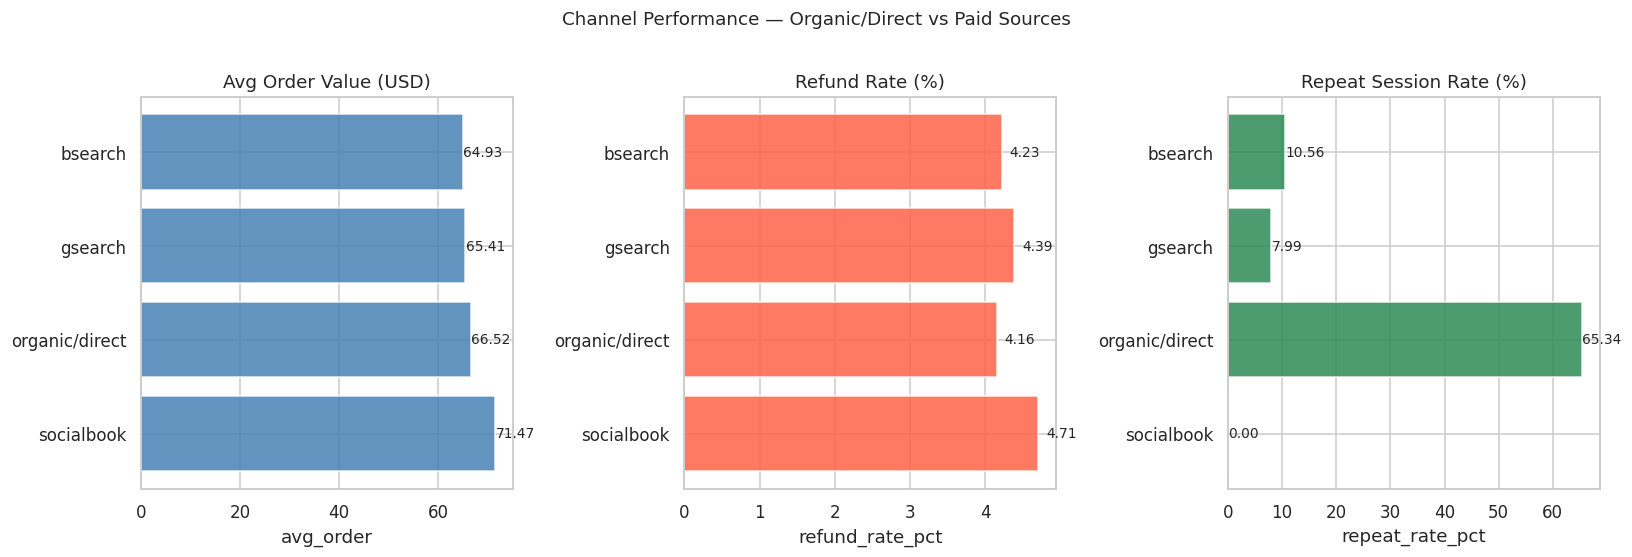

In [10]:
channel_summary = (
    df.groupby('traffic_type')
    .agg(
        orders      = ('order_id', 'count'),
        revenue     = ('order_price_usd', 'sum'),
        avg_order   = ('order_price_usd', 'mean'),
        refund_rate = ('is_refunded', 'mean'),
        repeat_rate = ('is_repeat_session', 'mean')
    )
    .reset_index()
)
channel_summary['refund_rate_pct'] = (channel_summary['refund_rate'] * 100).round(2)
channel_summary['repeat_rate_pct'] = (channel_summary['repeat_rate'] * 100).round(2)
channel_summary['rev_share']       = (channel_summary['revenue'] / channel_summary['revenue'].sum() * 100).round(1)

print('Channel Performance Breakdown:')
print(channel_summary[['traffic_type','orders','revenue','avg_order','refund_rate_pct','repeat_rate_pct','rev_share']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['avg_order', 'refund_rate_pct', 'repeat_rate_pct']
titles  = ['Avg Order Value (USD)', 'Refund Rate (%)', 'Repeat Session Rate (%)']
colors  = ['steelblue', 'tomato', 'seagreen']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.barh(channel_summary['traffic_type'], channel_summary[metric], color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(metric)
    for i, v in enumerate(channel_summary[metric]):
        ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Channel Performance — Organic/Direct vs Paid Sources', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

Customers coming through organic or direct traffic appear to be the most valuable group. They spend more on average, request fewer refunds, and return more often than customers from other channels. This suggests many of them are loyal customers who already know the brand, either through repeat visits or word of mouth.

On the other hand, customers from `socialbook` place high-value orders but also have the highest refund rate. This could mean the marketing is attracting attention, but the product experience may not fully match customer expectations.

Overall, the data suggests the business is heavily focused on acquiring new customers through ads, while the customers who already trust the brand are not being actively retained or rewarded enough.


## Proposed Strategy — Use Cross-Selling to Increase Revenue

One of the clearest opportunities in the data is cross-selling. Many customers who bought Mr. Fuzzy also purchased Hudson River Mini, but Hudson River Mini launched later, meaning older Mr. Fuzzy customers were never offered it.

A simple way to test this would be to send a targeted email campaign to past Mr. Fuzzy buyers who never purchased Hudson River Mini. One group would receive a product offer, while another receives a normal re-engagement email. Comparing the results over 30 days would show whether the cross-sell strategy works.

The main challenge is that older customers may no longer engage with emails, and actual conversion rates will likely be lower than the natural pairing rate seen in purchase data. Also, since this analysis only uses transaction data, it’s unclear whether customers were never shown the product or simply chose not to buy it.


In [11]:
# Estimate the addressable audience and potential revenue upside

hudson_launch = pd.Timestamp('2014-02-05')

# Mr. Fuzzy single-item buyers before Hudson River launched
pre_launch_fuzzy = df[
    (df['product_name'] == 'The Original Mr. Fuzzy') &
    (df['order_created_at'] < hudson_launch) &
    (df['items_purchased'] == 1)
]['user_id_x'].unique()

# Of those, who later bought Hudson River (already converted naturally)
post_launch_hudson_buyers = df[
    (df['product_name'] == 'The Hudson River Mini bear') &
    (df['order_created_at'] >= hudson_launch)
]['user_id_x'].unique()

untapped_audience = len(set(pre_launch_fuzzy) - set(post_launch_hudson_buyers))

hudson_price = df[df['product_name']=='The Hudson River Mini bear']['item_price_usd'].median()
hudson_margin = 0.647  # from product_summary above

conversion_scenarios = [0.02, 0.035, 0.05]
print('Cross-sell campaign revenue model:')
print(f'Addressable audience (pre-launch single-item Fuzzy buyers not yet converted): {untapped_audience:,}')
print(f'Hudson River Mini median price: ${hudson_price:.2f}')
print(f'Product gross margin: {hudson_margin*100:.1f}%\n')
print(f'{"Conversion Rate":<18} {"Orders":<10} {"Revenue":<14} {"Gross Profit"}')
print('-' * 55)
for conv in conversion_scenarios:
    orders = int(untapped_audience * conv)
    rev = orders * hudson_price
    gp  = rev * hudson_margin
    print(f'{conv*100:<18.1f}% {orders:<10,} ${rev:<13,.2f} ${gp:,.2f}')

Cross-sell campaign revenue model:
Addressable audience (pre-launch single-item Fuzzy buyers not yet converted): 9,130
Hudson River Mini median price: $29.99
Product gross margin: 64.7%

Conversion Rate    Orders     Revenue        Gross Profit
-------------------------------------------------------
2.0               % 182        $5,458.18      $3,531.44
3.5               % 319        $9,566.81      $6,189.73
5.0               % 456        $13,675.44     $8,848.01


## Summary of Key Findings

* Refunds spike during August and September, especially for Mr. Fuzzy, pointing to a recurring seasonal issue that should be fixed early.

* Hudson River Mini performs best as a cross-sell product, showing strong potential for bundles and upselling.

* Forever Love Bear gets a clear Valentine’s Day boost, suggesting seasonal campaigns could drive even more sales.

* Birthday Sugar Panda has the highest and growing refund rate, so product quality or customer expectations may need review.

* Organic and direct customers spend more and refund less, making them valuable customers to retain through loyalty and email campaigns.

**Overall:**
The business is good at attracting new customers, but the most valuable ones are the returning customers. Improving refunds and using stronger cross-sell strategies could have the biggest impact on growth.
